## *This notebook is adapted from* [LSSTDESC/CCLX: CellsCorrelations.ipynb](https://github.com/LSSTDESC/CCLX/blob/master/CellsCorrelations.ipynb)  

# Purpose

This example demonstrates how to use the **Core Cosmology Library (CCL)** to compute, analyze, and visualize key cosmological observables derived from a given cosmological model.  
It provides a step-by-step illustration of how theoretical predictions, such as **angular power spectra** and **two-point correlation functions**, are obtained from input cosmological parameters and galaxy distributions.

## Overview

The script performs the following tasks:

1. **Defining a cosmology** with key parameters (e.g., Ωₘ, σ₈, h).  
2. **Creating galaxy samples** using a redshift distribution and bias model.  
3. **Constructing CCL tracers** for weak lensing, galaxy clustering, and CMB lensing.  
4. **Calculating angular power spectra** (Cₗ) for various tracers and their cross-correlations.  
5. **Computing and plotting correlation functions** (ξ₊, ξ₋, ξ) from the angular spectra.  


**Define a Cosmology**  
   - Initializes a `pyccl.Cosmology` object with parameters such as matter density (Ωₘ), baryon density (Ω_b), Hubble constant (h), scalar spectral index (n_s), and power spectrum normalization (σ₈).  
   - This forms the basis for all subsequent calculations.

**Model a Galaxy Sample**  
   - Creates a redshift distribution, *p(z)*, representing the number of galaxies as a function of redshift.  
   - Applies a constant galaxy bias and visualizes the resulting distribution.

**Construct CCL Tracers**  
   - Defines **Weak Lensing** and **Number Counts** tracers to describe how galaxies trace the underlying matter field.  
   - Demonstrates how to include or exclude **Intrinsic Alignments (IA)** and **Redshift Space Distortions (RSD)** in tracer definitions.

**Compute Angular Power Spectra (Cₗ)**  
   - Calculates the auto- and cross-power spectra for lensing, clustering, and CMB lensing using CCL’s `angular_cl` function.  
   - Visualizes how intrinsic alignments and cross-correlations affect the results.

**Calculate Correlation Functions (ξ)**  
   - Converts the computed Cₗ spectra into **real-space two-point correlation functions**, such as ξ₊ and ξ₋ for shear, and ξ for galaxy clustering.  
   - Plots the angular dependence of these correlations to show how structure is distributed across the sky.

## Purpose in Context

This script serves as a pedagogical example for cosmology students and researchers interested in:
- Learning how **CCL** bridges theory and observation.  
- Understanding the workflow from cosmological parameters → observables.  
- Exploring how different physical effects (bias, IA, RSD, CMB lensing) impact measurable quantities.

It can be adapted for more complex analyses, including tomographic binning, parameter variation, or comparison with observational data.

# Library Installation

In [1]:
!pip install -q pyccl camb

# Example: $C_\ell$ and Correlation Functions with CCL

In this example, we demonstrate how to use **CCL (Core Cosmology Library)** to compute key cosmological observables — including **angular power spectra** ($C_\ell$) and **correlation functions**.  

In [2]:
import numpy as np
import pylab as plt
import pyccl as ccl

## Defining a Cosmology

The first step is to create a **cosmology object**, which specifies the fundamental parameters of the Universe.

In [3]:
cosmo = ccl.Cosmology(Omega_c = 0.27, Omega_b = 0.045, h = 0.67, sigma8 = 0.83, n_s = 0.96)

## Defining a Galaxy Sample

We define a sample of galaxies using a **redshift distribution**.  
Additionally, we specify their **bias parameter**, which is assumed to be constant in this example.

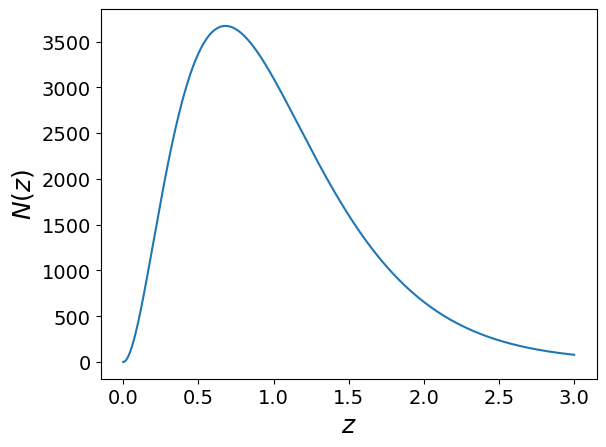

In [4]:
z = np.linspace(0., 3., 512)
i_lim = 26. # Limiting i-band magnitude
z0 = 0.0417*i_lim - 0.744

Ngal = 46. * 100.31 * (i_lim - 25.) # Normalisation, galaxies/arcmin^2
pz = 1./(2.*z0) * (z / z0)**2. * np.exp(-z/z0) # Redshift distribution, p(z)
dNdz = Ngal * pz # Number density distribution
b = 1.5*np.ones(512) #Galaxy bias (constant with scale and z)

plt.xlabel('$z$',fontsize=18)
plt.ylabel('$N(z)$',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.plot(z, dNdz)
plt.show()

## Creating Tracer Objects

In CCL, **Tracer objects** handle both auto- and cross-spectrum calculations.  
For this example, we define two tracers: one for **lensing** and one for **clustering**.  
For more general tracer definitions, see the *GeneralizedTracers* notebook and the CCL documentation.

In [5]:
lens1 = ccl.WeakLensingTracer(cosmo, dndz=(z, dNdz)) #CCL automatically normalizes dNdz
clu1 = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z,dNdz), bias=(z,b))

For the **clustering tracer**, we exclude **RSD bias** by setting the corresponding flag to `False`.  
Similarly, for the **lensing tracer**, **intrinsic alignments (IA)** are excluded.  
To include intrinsic alignments, we can define a tracer that incorporates an **IA amplitude** as a function of redshift.

In [6]:
bias_ia = 1*np.ones_like(z) #A_IA=1 in the NLA model
lens1_ia = ccl.WeakLensingTracer(cosmo, dndz = (z,dNdz), ia_bias = (z,bias_ia))

## Calculating Angular Power Spectra

Once the tracers are defined, we can compute the **angular power spectra** ($C_\ell$).  
First, we specify the **angular multipoles** of interest, and then calculate the spectra:

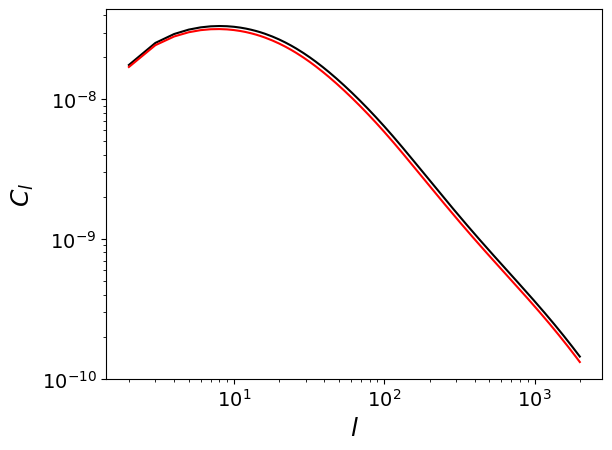

In [7]:
ell = np.arange(2, 2000)

cls = ccl.angular_cl(cosmo, lens1, lens1, ell) #Cosmic shear
cls_ia = ccl.angular_cl(cosmo, lens1_ia, lens1_ia, ell) #Cosmic shear with IA
cls_clu = ccl.angular_cl(cosmo, clu1, clu1, ell) #Clustering

plt.xlabel('$l$',fontsize=18)
plt.ylabel('$C_l$',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xscale('log')
plt.plot(ell, cls, 'k-')
plt.plot(ell, cls_ia, 'r-')
plt.show()

### CMB Lensing Cross-Correlation

CCL also provides the ability to compute **CMB lensing angular power spectra**.

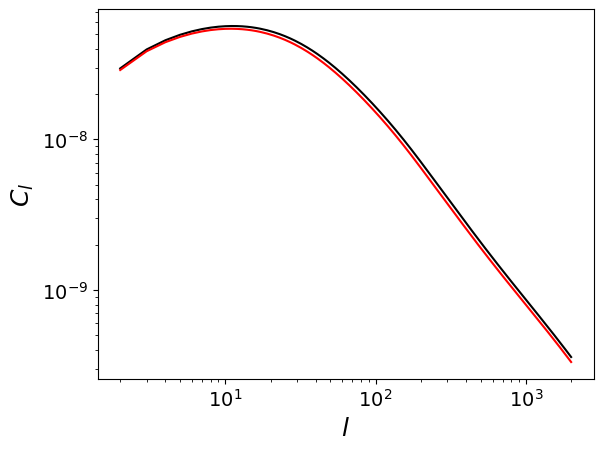

In [8]:
cmbl = ccl.CMBLensingTracer(cosmo, z_source=1090.)
cls_cmb_cross_lens1 = ccl.angular_cl(cosmo, lens1, cmbl, ell)
cls_cmb_cross_lens1ia = ccl.angular_cl(cosmo,lens1_ia,cmbl, ell)

plt.xlabel('$l$',fontsize=18)
plt.ylabel('$C_l$',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xscale('log')
plt.plot(ell, cls_cmb_cross_lens1, 'k-')
plt.plot(ell, cls_cmb_cross_lens1ia, 'r-')
plt.show()

## Correlation Functions

Next, we demonstrate how CCL can compute **correlation functions**.  
First, we define the **angular scales** at which the correlations will be evaluated.  
Then, we obtain the predicted correlations.  

> **Note:** This calculation relies on the previously computed $C_\ell$ values.

In [9]:
theta_deg = np.logspace(-1, np.log10(5.), 20) # Theta is in degrees

#Cosmic shear:
xi_plus = ccl.correlation(cosmo, ell=ell, C_ell=cls, theta=theta_deg, type='GG+', method='FFTLog')
xi_minus = ccl.correlation(cosmo, ell=ell, C_ell=cls, theta=theta_deg, type='GG-', method='FFTLog')
#Cosmic shear with IA:
xi_plus_ia = ccl.correlation(cosmo, ell=ell, C_ell=cls_ia, theta=theta_deg, type='GG+', method='FFTLog')
#Clustering:
xi_clu = ccl.correlation(cosmo, ell=ell, C_ell=cls_clu, theta=theta_deg, type='NN', method='FFTLog')

We can then **plot the correlation functions**, starting with **lensing**:

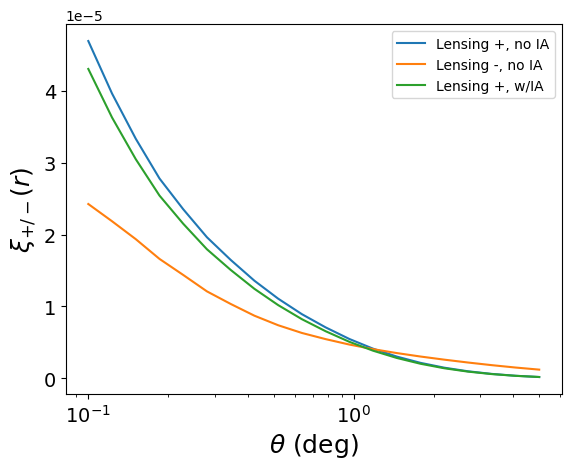

In [10]:
plt.plot(theta_deg, xi_plus, label='Lensing +, no IA')
plt.plot(theta_deg, xi_minus, label='Lensing -, no IA')
plt.plot(theta_deg, xi_plus_ia, label='Lensing +, w/IA')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xscale('log')
plt.legend(loc='upper right')
plt.xlabel(r'$\theta$ (deg)',fontsize=18)
plt.ylabel(r'$\xi_{+/-} (r)$',fontsize=18)
plt.show()

Next, we plot the correlation functions for **galaxy–galaxy clustering**:

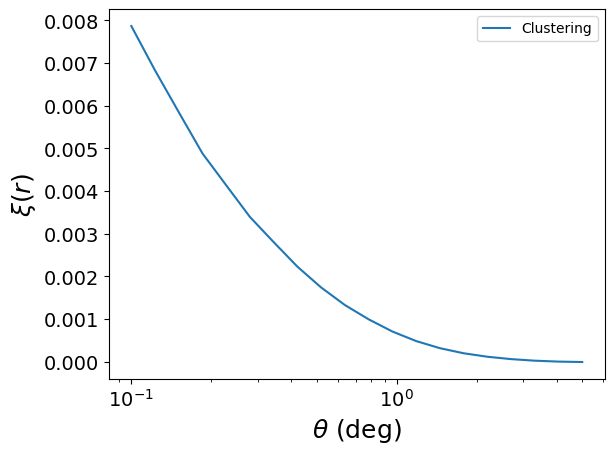

In [11]:
plt.plot(theta_deg, xi_clu, label='Clustering')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xscale('log')
plt.legend(loc='upper right')
plt.xlabel(r'$\theta$ (deg)',fontsize=18)
plt.ylabel(r'$\xi (r)$',fontsize=18)
plt.show()